# 04 - Ablation Studies

This notebook evaluates the robustness and reproducibility of the DenseNet-Attention model
through systematic ablation studies:

1. Data augmentation level (none / basic / standard / heavy)
2. Training set size (25% / 50% / 75% / 100%)
3. Model components (attention module, focal loss)
4. Multiple runs with different random seeds

In [1]:
import sys
sys.path.insert(0, "..")

import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import get_dataloaders
from src.models import get_model
from src.train import run_experiment
from src.evaluate import evaluate_model, compute_metrics
from src.utils import set_seed, get_device, load_config, save_results

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

config = load_config("../configs/default.yaml")
device = get_device()
DATA_ROOT = "../data/chest_xray"
SEED = config["reproducibility"]["seed"]
SEEDS = config["reproducibility"]["seeds_for_multiple_runs"]

print(f"Device: {device}")
print(f"Seeds for multi-run experiments: {SEEDS}")

Device: cuda
Seeds for multi-run experiments: [42, 123, 456, 789, 1024]


In [2]:
def run_single_ablation(model_kwargs, data_kwargs, run_config, experiment_name, seed=42):
    """Train a single model and return test metrics."""
    set_seed(seed)

    dataloaders = get_dataloaders(
        DATA_ROOT,
        num_workers=0,
        seed=seed,
        **data_kwargs,
    )

    model = get_model("densenet_attention", **model_kwargs)

    history = run_experiment(
        model_name="densenet_attention",
        model=model,
        dataloaders=dataloaders,
        device=device,
        config=run_config,
        experiment_name=experiment_name,
    )

    test_results = evaluate_model(model, dataloaders["test"], device)
    return test_results["metrics"], history

## Ablation 1: Data Augmentation Level

We train the DenseNet-Attention model with four different augmentation strategies
to quantify the impact of data augmentation on generalization.

In [3]:
aug_levels = ["none", "basic", "standard", "heavy"]
aug_results = {}

for level in aug_levels:
    print(f"\n{'='*60}")
    print(f"Training with augmentation: {level}")
    print(f"{'='*60}")

    data_kwargs = {
        "augmentation": level,
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
    }
    model_kwargs = {
        "pretrained": True,
        "dropout": config["model"]["dropout"],
        "use_attention": True,
    }

    metrics, _ = run_single_ablation(
        model_kwargs, data_kwargs, config,
        experiment_name=f"ablation_aug_{level}",
        seed=SEED,
    )
    aug_results[level] = metrics
    print(f"  AUROC: {metrics['auroc']:.4f}, F1: {metrics['f1_macro']:.4f}")


Training with augmentation: none
Epoch   1/15 | Train Loss: 0.0147 | Val Loss: 0.0086 | Val AUROC: 0.9986 | F1: 0.9586 *
Epoch   2/15 | Train Loss: 0.0052 | Val Loss: 0.0068 | Val AUROC: 0.9985 | F1: 0.9820 
Epoch   3/15 | Train Loss: 0.0028 | Val Loss: 0.0048 | Val AUROC: 0.9993 | F1: 0.9850 *
Epoch   4/15 | Train Loss: 0.0014 | Val Loss: 0.0037 | Val AUROC: 0.9997 | F1: 0.9882 *
Epoch   5/15 | Train Loss: 0.0012 | Val Loss: 0.0063 | Val AUROC: 0.9996 | F1: 0.9745 
Epoch   6/15 | Train Loss: 0.0004 | Val Loss: 0.0035 | Val AUROC: 0.9995 | F1: 0.9883 
Epoch   7/15 | Train Loss: 0.0011 | Val Loss: 0.0021 | Val AUROC: 0.9998 | F1: 0.9933 *
Epoch   8/15 | Train Loss: 0.0007 | Val Loss: 0.0036 | Val AUROC: 0.9996 | F1: 0.9883 
Epoch   9/15 | Train Loss: 0.0002 | Val Loss: 0.0042 | Val AUROC: 0.9996 | F1: 0.9950 
Epoch  10/15 | Train Loss: 0.0001 | Val Loss: 0.0033 | Val AUROC: 0.9998 | F1: 0.9917 
Epoch  11/15 | Train Loss: 0.0001 | Val Loss: 0.0025 | Val AUROC: 0.9998 | F1: 0.9933 *
Epoc

c:\git\HSLU\HSLU.MEDIMG.Project\notebooks\..\src\data.py:122: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=30, max_width=30, p=0.2),


Epoch   1/15 | Train Loss: 0.0269 | Val Loss: 0.0118 | Val AUROC: 0.9968 | F1: 0.9497 *
Epoch   2/15 | Train Loss: 0.0162 | Val Loss: 0.0083 | Val AUROC: 0.9976 | F1: 0.9753 *
Epoch   3/15 | Train Loss: 0.0139 | Val Loss: 0.0097 | Val AUROC: 0.9974 | F1: 0.9754 
Epoch   4/15 | Train Loss: 0.0124 | Val Loss: 0.0060 | Val AUROC: 0.9982 | F1: 0.9818 *
Epoch   5/15 | Train Loss: 0.0106 | Val Loss: 0.0080 | Val AUROC: 0.9970 | F1: 0.9797 
Epoch   6/15 | Train Loss: 0.0090 | Val Loss: 0.0057 | Val AUROC: 0.9979 | F1: 0.9833 
Epoch   7/15 | Train Loss: 0.0085 | Val Loss: 0.0104 | Val AUROC: 0.9974 | F1: 0.9754 
Epoch   8/15 | Train Loss: 0.0072 | Val Loss: 0.0092 | Val AUROC: 0.9977 | F1: 0.9738 
Epoch   9/15 | Train Loss: 0.0060 | Val Loss: 0.0071 | Val AUROC: 0.9976 | F1: 0.9817 
Early stopping at epoch 9 (no improvement for 5 epochs)
  AUROC: 0.9839, F1: 0.8383


Augmentation    AUROC  F1 (macro)  Sensitivity  Specificity
        none 0.964048    0.746253     1.000000     0.461538
       basic 0.933602    0.616014     1.000000     0.260684
    standard 0.988648    0.883473     0.994872     0.735043
       heavy 0.983892    0.838252     0.997436     0.636752


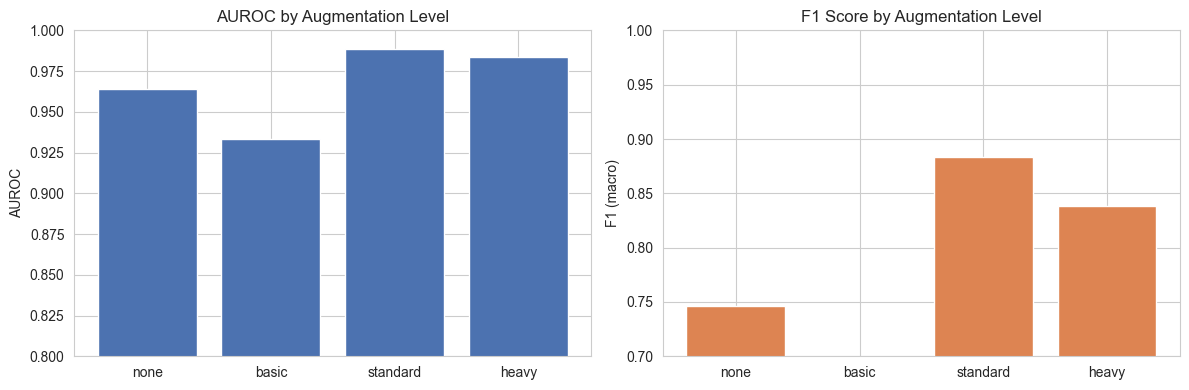

In [4]:
aug_df = pd.DataFrame([
    {"Augmentation": level, "AUROC": r["auroc"], "F1 (macro)": r["f1_macro"],
     "Sensitivity": r["sensitivity"], "Specificity": r["specificity"]}
    for level, r in aug_results.items()
])
print(aug_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(aug_df["Augmentation"], aug_df["AUROC"], color="#4C72B0")
axes[0].set_ylabel("AUROC")
axes[0].set_title("AUROC by Augmentation Level")
axes[0].set_ylim(0.8, 1.0)

axes[1].bar(aug_df["Augmentation"], aug_df["F1 (macro)"], color="#DD8452")
axes[1].set_ylabel("F1 (macro)")
axes[1].set_title("F1 Score by Augmentation Level")
axes[1].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig("../results/ablation_augmentation.png", bbox_inches="tight")
plt.show()

## Ablation 2: Training Set Size

We evaluate how performance degrades as the amount of training data decreases.
This is relevant in medical imaging where labeled data is often scarce.

In [5]:
fractions = [0.25, 0.50, 0.75, 1.0]
size_results = {}

for frac in fractions:
    print(f"\n{'='*60}")
    print(f"Training with {frac*100:.0f}% of training data")
    print(f"{'='*60}")

    data_kwargs = {
        "augmentation": "standard",
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
        "train_fraction": frac,
    }
    model_kwargs = {
        "pretrained": True,
        "dropout": config["model"]["dropout"],
        "use_attention": True,
    }

    metrics, _ = run_single_ablation(
        model_kwargs, data_kwargs, config,
        experiment_name=f"ablation_size_{int(frac*100)}",
        seed=SEED,
    )
    size_results[frac] = metrics
    print(f"  AUROC: {metrics['auroc']:.4f}, F1: {metrics['f1_macro']:.4f}")


Training with 25% of training data
Epoch   1/15 | Train Loss: 0.0377 | Val Loss: 0.0149 | Val AUROC: 0.9933 | F1: 0.9577 *
Epoch   2/15 | Train Loss: 0.0152 | Val Loss: 0.0106 | Val AUROC: 0.9955 | F1: 0.9652 *
Epoch   3/15 | Train Loss: 0.0125 | Val Loss: 0.0095 | Val AUROC: 0.9962 | F1: 0.9703 *
Epoch   4/15 | Train Loss: 0.0131 | Val Loss: 0.0213 | Val AUROC: 0.9972 | F1: 0.9326 *
Epoch   5/15 | Train Loss: 0.0103 | Val Loss: 0.0149 | Val AUROC: 0.9963 | F1: 0.9644 
Epoch   6/15 | Train Loss: 0.0075 | Val Loss: 0.0107 | Val AUROC: 0.9962 | F1: 0.9705 
Epoch   7/15 | Train Loss: 0.0069 | Val Loss: 0.0094 | Val AUROC: 0.9970 | F1: 0.9721 
Epoch   8/15 | Train Loss: 0.0047 | Val Loss: 0.0098 | Val AUROC: 0.9969 | F1: 0.9721 
Epoch   9/15 | Train Loss: 0.0030 | Val Loss: 0.0100 | Val AUROC: 0.9972 | F1: 0.9722 *
Epoch  10/15 | Train Loss: 0.0030 | Val Loss: 0.0111 | Val AUROC: 0.9962 | F1: 0.9738 
Epoch  11/15 | Train Loss: 0.0015 | Val Loss: 0.0129 | Val AUROC: 0.9964 | F1: 0.9722 
Ep

Train Fraction    AUROC  F1 (macro)  Sensitivity  Specificity
           25% 0.984221    0.831876     0.997436     0.623932
           50% 0.972606    0.695687     0.997436     0.380342
           75% 0.979772    0.867547     0.994872     0.700855
          100% 0.988878    0.863868     0.992308     0.696581


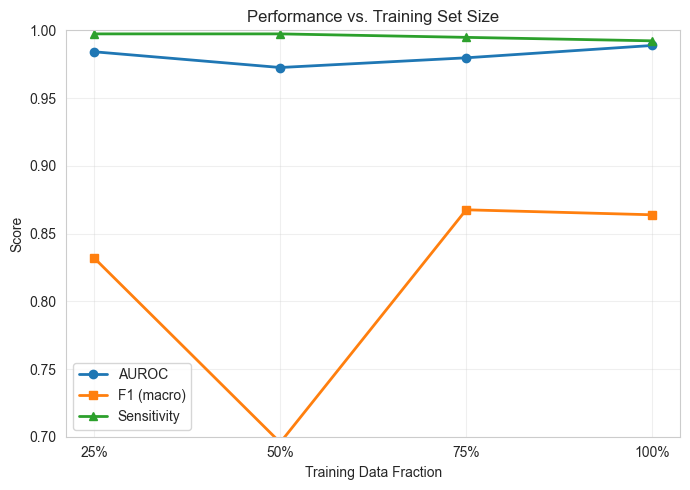

In [6]:
size_df = pd.DataFrame([
    {"Train Fraction": f"{frac*100:.0f}%", "AUROC": r["auroc"],
     "F1 (macro)": r["f1_macro"], "Sensitivity": r["sensitivity"],
     "Specificity": r["specificity"]}
    for frac, r in size_results.items()
])
print(size_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
x = [f"{f*100:.0f}%" for f in fractions]
ax.plot(x, [size_results[f]["auroc"] for f in fractions], "o-", label="AUROC", linewidth=2)
ax.plot(x, [size_results[f]["f1_macro"] for f in fractions], "s-", label="F1 (macro)", linewidth=2)
ax.plot(x, [size_results[f]["sensitivity"] for f in fractions], "^-", label="Sensitivity", linewidth=2)
ax.set_xlabel("Training Data Fraction")
ax.set_ylabel("Score")
ax.set_title("Performance vs. Training Set Size")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig("../results/ablation_data_size.png", bbox_inches="tight")
plt.show()

## Ablation 3: Model Components

We study the contribution of two key design choices:
- Channel attention module
- Focal loss (vs. weighted BCE)

In [7]:
component_configs = {
    "Full model (attention + focal)": {"use_attention": True, "use_focal": True},
    "No attention": {"use_attention": False, "use_focal": True},
    "No focal loss": {"use_attention": True, "use_focal": False},
    "No attention, no focal": {"use_attention": False, "use_focal": False},
}

component_results = {}

for name, comp_cfg in component_configs.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    data_kwargs = {
        "augmentation": "standard",
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
    }
    model_kwargs = {
        "pretrained": True,
        "dropout": config["model"]["dropout"],
        "use_attention": comp_cfg["use_attention"],
    }

    run_config = copy.deepcopy(config)
    run_config["model"]["use_focal_loss"] = comp_cfg["use_focal"]

    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
    metrics, _ = run_single_ablation(
        model_kwargs, data_kwargs, run_config,
        experiment_name=f"ablation_component_{safe_name}",
        seed=SEED,
    )
    component_results[name] = metrics
    print(f"  AUROC: {metrics['auroc']:.4f}, F1: {metrics['f1_macro']:.4f}")


Training: Full model (attention + focal)
Epoch   1/15 | Train Loss: 0.0214 | Val Loss: 0.0076 | Val AUROC: 0.9974 | F1: 0.9785 *
Epoch   2/15 | Train Loss: 0.0119 | Val Loss: 0.0103 | Val AUROC: 0.9976 | F1: 0.9691 *
Epoch   3/15 | Train Loss: 0.0096 | Val Loss: 0.0056 | Val AUROC: 0.9982 | F1: 0.9851 *
Epoch   4/15 | Train Loss: 0.0078 | Val Loss: 0.0097 | Val AUROC: 0.9965 | F1: 0.9722 
Epoch   5/15 | Train Loss: 0.0068 | Val Loss: 0.0119 | Val AUROC: 0.9976 | F1: 0.9438 
Epoch   6/15 | Train Loss: 0.0060 | Val Loss: 0.0078 | Val AUROC: 0.9978 | F1: 0.9803 
Epoch   7/15 | Train Loss: 0.0052 | Val Loss: 0.0099 | Val AUROC: 0.9972 | F1: 0.9770 
Epoch   8/15 | Train Loss: 0.0040 | Val Loss: 0.0070 | Val AUROC: 0.9984 | F1: 0.9819 *
Epoch   9/15 | Train Loss: 0.0036 | Val Loss: 0.0078 | Val AUROC: 0.9984 | F1: 0.9835 *
Epoch  10/15 | Train Loss: 0.0025 | Val Loss: 0.0119 | Val AUROC: 0.9982 | F1: 0.9771 
Epoch  11/15 | Train Loss: 0.0023 | Val Loss: 0.0070 | Val AUROC: 0.9982 | F1: 0.98

                 Configuration    AUROC  F1 (macro)  Sensitivity  Specificity
Full model (attention + focal) 0.981514    0.891299     0.994872     0.752137
                  No attention 0.989283    0.900722     0.997436     0.769231
                 No focal loss 0.980775    0.854949     0.997436     0.670940
        No attention, no focal 0.988785    0.899279     0.992308     0.773504


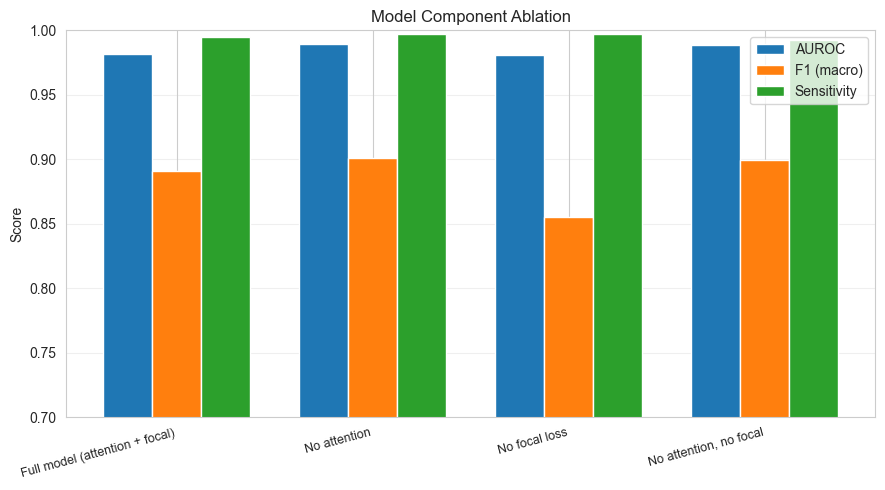

In [8]:
comp_df = pd.DataFrame([
    {"Configuration": name, "AUROC": r["auroc"], "F1 (macro)": r["f1_macro"],
     "Sensitivity": r["sensitivity"], "Specificity": r["specificity"]}
    for name, r in component_results.items()
])
print(comp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(component_results))
width = 0.25

names = list(component_results.keys())
aurocs = [component_results[n]["auroc"] for n in names]
f1s = [component_results[n]["f1_macro"] for n in names]
sens = [component_results[n]["sensitivity"] for n in names]

ax.bar(x - width, aurocs, width, label="AUROC")
ax.bar(x, f1s, width, label="F1 (macro)")
ax.bar(x + width, sens, width, label="Sensitivity")

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Model Component Ablation")
ax.legend()
ax.set_ylim(0.7, 1.0)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../results/ablation_components.png", bbox_inches="tight")
plt.show()

## Multiple Runs with Different Seeds

To assess variability, we run the full DenseNet-Attention model 5 times
with different random initializations.

In [9]:
multi_run_results = []

for i, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"Run {i+1}/{len(SEEDS)} with seed={seed}")
    print(f"{'='*60}")

    data_kwargs = {
        "augmentation": "standard",
        "image_size": config["data"]["image_size"],
        "batch_size": config["training"]["batch_size"],
        "val_split": config["data"]["val_split"],
    }
    model_kwargs = {
        "pretrained": True,
        "dropout": config["model"]["dropout"],
        "use_attention": True,
    }

    metrics, _ = run_single_ablation(
        model_kwargs, data_kwargs, config,
        experiment_name=f"multirun_seed_{seed}",
        seed=seed,
    )
    multi_run_results.append({"seed": seed, **metrics})
    print(f"  AUROC: {metrics['auroc']:.4f}, F1: {metrics['f1_macro']:.4f}")


Run 1/5 with seed=42
Epoch   1/15 | Train Loss: 0.0217 | Val Loss: 0.0084 | Val AUROC: 0.9970 | F1: 0.9662 *
Epoch   2/15 | Train Loss: 0.0120 | Val Loss: 0.0066 | Val AUROC: 0.9985 | F1: 0.9818 *
Epoch   3/15 | Train Loss: 0.0091 | Val Loss: 0.0071 | Val AUROC: 0.9972 | F1: 0.9819 
Epoch   4/15 | Train Loss: 0.0081 | Val Loss: 0.0057 | Val AUROC: 0.9982 | F1: 0.9832 
Epoch   5/15 | Train Loss: 0.0071 | Val Loss: 0.0045 | Val AUROC: 0.9989 | F1: 0.9917 *
Epoch   6/15 | Train Loss: 0.0064 | Val Loss: 0.0061 | Val AUROC: 0.9992 | F1: 0.9835 *
Epoch   7/15 | Train Loss: 0.0057 | Val Loss: 0.0073 | Val AUROC: 0.9968 | F1: 0.9832 
Epoch   8/15 | Train Loss: 0.0040 | Val Loss: 0.0065 | Val AUROC: 0.9970 | F1: 0.9866 
Epoch   9/15 | Train Loss: 0.0036 | Val Loss: 0.0067 | Val AUROC: 0.9986 | F1: 0.9819 
Epoch  10/15 | Train Loss: 0.0026 | Val Loss: 0.0080 | Val AUROC: 0.9981 | F1: 0.9819 
Epoch  11/15 | Train Loss: 0.0022 | Val Loss: 0.0106 | Val AUROC: 0.9982 | F1: 0.9770 
Early stopping at

In [10]:
mr_df = pd.DataFrame(multi_run_results)

print("Per-run results:")
print(mr_df[["seed", "auroc", "f1_macro", "sensitivity", "specificity"]].to_string(index=False))

print("\nAggregated statistics:")
for col in ["auroc", "f1_macro", "sensitivity", "specificity", "npv"]:
    mean = mr_df[col].mean()
    std = mr_df[col].std()
    print(f"  {col:>15s}: {mean:.4f} +/- {std:.4f}")

Per-run results:
 seed    auroc  f1_macro  sensitivity  specificity
   42 0.985810  0.854949     0.997436     0.670940
  123 0.969297  0.748723     1.000000     0.465812
  456 0.988231  0.854949     0.997436     0.670940
  789 0.982457  0.885438     0.994872     0.739316
 1024 0.983311  0.897359     0.992308     0.769231

Aggregated statistics:
            auroc: 0.9818 +/- 0.0074
         f1_macro: 0.8483 +/- 0.0587
      sensitivity: 0.9964 +/- 0.0029
      specificity: 0.6632 +/- 0.1184
              npv: 0.9919 +/- 0.0062


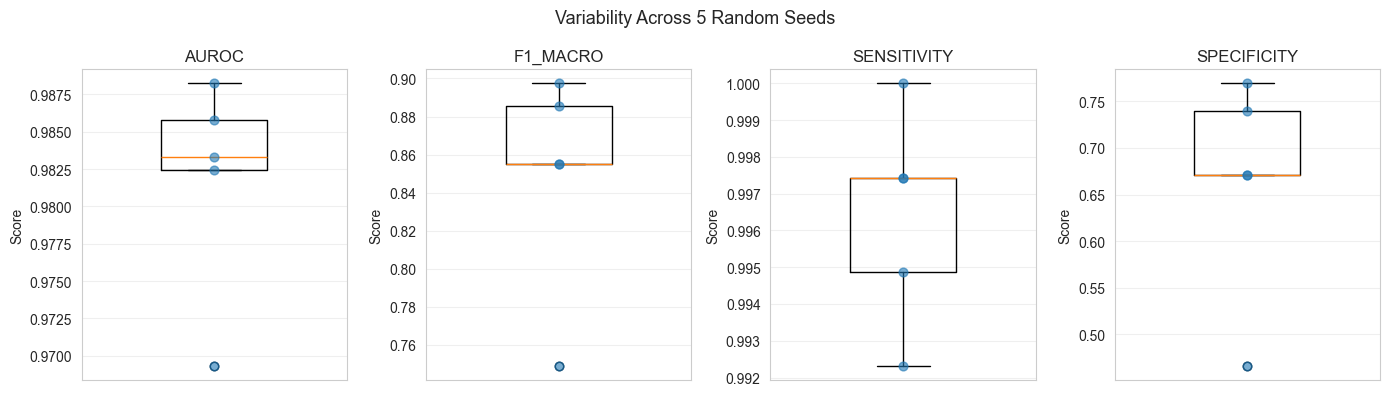

In [11]:
metrics_to_plot = ["auroc", "f1_macro", "sensitivity", "specificity"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 4))

for i, metric in enumerate(metrics_to_plot):
    values = mr_df[metric].values
    axes[i].boxplot(values, widths=0.4)
    axes[i].scatter(np.ones(len(values)), values, alpha=0.6, s=40, zorder=3)
    axes[i].set_title(metric.upper())
    axes[i].set_ylabel("Score")
    axes[i].set_xticks([])
    axes[i].grid(True, alpha=0.3, axis="y")

plt.suptitle("Variability Across 5 Random Seeds", fontsize=13)
plt.tight_layout()
plt.savefig("../results/ablation_multirun.png", bbox_inches="tight")
plt.show()

## Save all ablation results

In [12]:
all_ablation_results = {
    "augmentation_ablation": {k: v for k, v in aug_results.items()},
    "data_size_ablation": {str(k): v for k, v in size_results.items()},
    "component_ablation": component_results,
    "multi_run": multi_run_results,
    "multi_run_summary": {
        col: {"mean": float(mr_df[col].mean()), "std": float(mr_df[col].std())}
        for col in ["auroc", "f1_macro", "sensitivity", "specificity", "npv"]
    },
}

save_results(all_ablation_results, "ablation_results", output_dir="../results")
print("All ablation results saved.")

All ablation results saved.


In [13]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()